# Data

In [ ]:
!unzip /content/drive/MyDrive/observing.zip

In [ ]:
!unzip /content/drive/MyDrive/public_test.zip

Archive:  /content/drive/MyDrive/public_test.zip
   creating: public_test/
   creating: public_test/samples/
   creating: public_test/samples/BlackBox_0/
   creating: public_test/samples/BlackBox_0/object_images/
  inflating: public_test/samples/BlackBox_0/object_images/img_1.jpg  
  inflating: public_test/samples/BlackBox_0/object_images/img_2.jpg  
  inflating: public_test/samples/BlackBox_0/object_images/img_3.jpg  
  inflating: public_test/samples/BlackBox_0/drone_video.mp4  
   creating: public_test/samples/BlackBox_1/
   creating: public_test/samples/BlackBox_1/object_images/
  inflating: public_test/samples/BlackBox_1/object_images/img_1.jpg  
  inflating: public_test/samples/BlackBox_1/object_images/img_2.jpg  
  inflating: public_test/samples/BlackBox_1/object_images/img_3.jpg  
  inflating: public_test/samples/BlackBox_1/drone_video.mp4  
   creating: public_test/samples/CardboardBox_0/
   creating: public_test/samples/CardboardBox_0/object_images/
  inflating: public_test/sa

In [ ]:
!unzip /content/drive/MyDrive/dataset_yolo.zip

# EDA phase 1

In [ ]:
import os
import json
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from typing import List, Dict, Any

class DroneDatasetEDA:
    def __init__(self, dataset_path: str):
        self.dataset_path = Path(dataset_path)
        self.samples_path = self.dataset_path / "samples"
        self.annotations_path = self.dataset_path / "annotations" / "annotations.json"
        self.annotations = self._load_annotations()

    def _load_annotations(self) -> Dict[str, Any]:
        with open(self.annotations_path, "r") as f:
            data = json.load(f)
        print(f"[INFO] Loaded annotations for {len(data)} videos.")
        return data

    def get_video_list(self) -> List[str]:
        return [d.name for d in self.samples_path.iterdir() if d.is_dir()]

    def summarize_annotations(self) -> pd.DataFrame:
        rows = []
        for record in self.annotations:
            video_id = record["video_id"]
            for ann in record["annotations"]:
                bboxes = ann["bboxes"]
                frames = [b["frame"] for b in bboxes]
                rows.append({
                    "video_id": video_id,
                    "num_boxes": len(bboxes),
                    "start_frame": min(frames),
                    "end_frame": max(frames),
                    "duration_frames": max(frames) - min(frames) + 1
                })
        df = pd.DataFrame(rows)
        print(f"[INFO] Annotation summary:\n{df.describe()}")
        return df

    def analyze_video_properties(self):
        stats = []
        for video_dir in self.samples_path.iterdir():
            if not video_dir.is_dir():
                continue
            video_path = video_dir / "drone_video.mp4"
            cap = cv2.VideoCapture(str(video_path))
            if not cap.isOpened():
                print(f"[WARN] Cannot open {video_path}")
                continue
            fps = cap.get(cv2.CAP_PROP_FPS)
            frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
            height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
            duration = frame_count / fps if fps else 0
            stats.append({
                "video_id": video_dir.name,
                "fps": fps,
                "frames": frame_count,
                "resolution": f"{width}x{height}",
                "duration_sec": duration
            })
            cap.release()
        df = pd.DataFrame(stats)
        print(f"[INFO] Video stats summary:\n{df.describe()}")
        return df

    def visualize_sample_bbox(self, video_id: str, frame_idx: int):
        """Show a frame with bounding box overlay."""
        video_path = self.samples_path / video_id / "drone_video.mp4"
        cap = cv2.VideoCapture(str(video_path))
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        cap.release()
        if not ret:
            print(f"[ERROR] Frame {frame_idx} not found in {video_id}")
            return

        # Get bounding box
        bboxes = []
        for record in self.annotations:
            if record["video_id"] == video_id:
                for ann in record["annotations"]:
                    for box in ann["bboxes"]:
                        if box["frame"] == frame_idx:
                            bboxes.append(box)
        for box in bboxes:
            x1, y1, x2, y2 = box["x1"], box["y1"], box["x2"], box["y2"]
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)

        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.title(f"{video_id} — Frame {frame_idx}")
        plt.axis("off")
        plt.show()

    def plot_visibility_timeline(self, df_ann: pd.DataFrame):
        plt.figure(figsize=(10, 6))
        for i, row in df_ann.iterrows():
            plt.hlines(y=i, xmin=row["start_frame"], xmax=row["end_frame"], color='g', linewidth=3)
        plt.xlabel("Frame Index")
        plt.ylabel("Video Segment")
        plt.title("Target Object Visibility Timeline per Video")
        plt.show()

    def inspect_object_images(self, video_id: str):
        obj_dir = self.samples_path / video_id / "object_images"
        imgs = sorted(obj_dir.glob("*.jpg"))
        if not imgs:
            print(f"[WARN] No object images found for {video_id}")
            return
        fig, axes = plt.subplots(1, len(imgs), figsize=(12, 4))
        # Ensure axes is always an array even for a single image
        if len(imgs) == 1:
            axes = [axes]
        for ax, img_path in zip(axes, imgs):
            img = cv2.imread(str(img_path))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax.imshow(img)
            ax.set_title(img_path.name)
            ax.axis("off")
        plt.suptitle(f"Reference Object Views — {video_id}")
        plt.show()

[INFO] Loaded annotations for 14 videos.
['Lifering_1', 'Backpack_0', 'WaterBottle_1', 'Backpack_1', 'Jacket_0', 'Jacket_1', 'WaterBottle_0', 'Lifering_0', 'Laptop_0', 'MobilePhone_0', 'Laptop_1', 'Person1_1', 'Person1_0', 'MobilePhone_1']
[INFO] Annotation summary:
         num_boxes   start_frame     end_frame  duration_frames
count   118.000000    118.000000    118.000000       118.000000
mean    171.322034   3502.771186   3672.161017       170.389831
std     184.132797   1933.325603   1988.674600       184.262310
min       7.000000     32.000000     74.000000         7.000000
25%      69.500000   2316.250000   2500.250000        69.500000
50%     127.500000   3383.500000   3558.000000       122.500000
75%     196.250000   4704.750000   4918.750000       196.250000
max    1436.000000  10418.000000  10465.000000      1435.000000
[INFO] Video stats summary:
        fps        frames  duration_sec
count  14.0     14.000000     14.000000
mean   25.0   5766.357143    230.654286
std     0

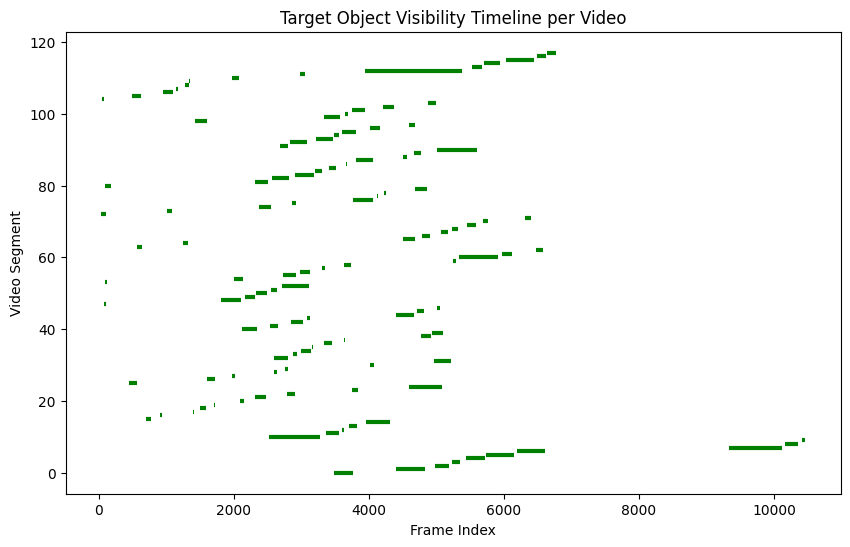

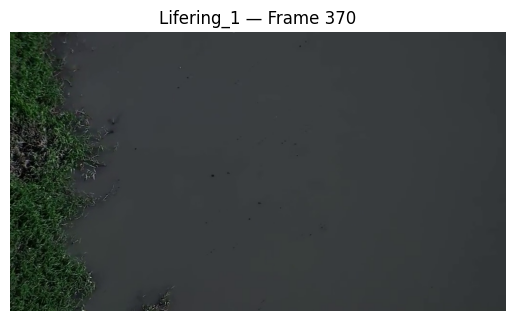

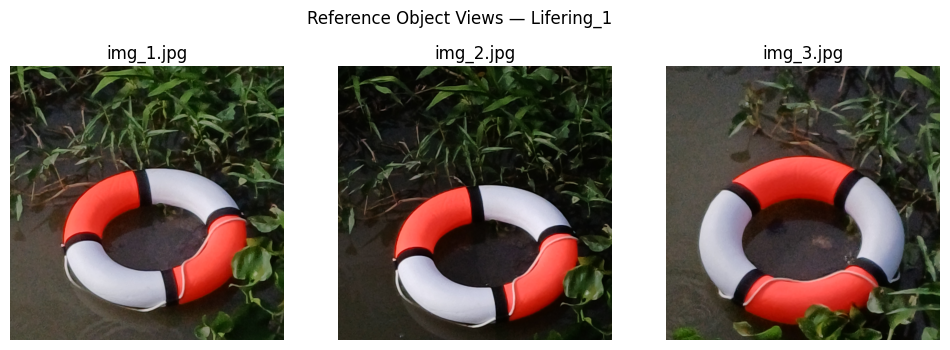

In [ ]:
if __name__ == "__main__":
    dataset_path = "train"
    eda = DroneDatasetEDA(dataset_path)

    video_list = eda.get_video_list()
    print(video_list)

    df_ann = eda.summarize_annotations()

    df_video = eda.analyze_video_properties()

    eda.plot_visibility_timeline(df_ann)

    # Use a valid video_id from the list for visualization and inspection
    if video_list:
        sample_video_id = video_list[0] # Using the first video in the list as an example
        eda.visualize_sample_bbox(sample_video_id, 370)
        eda.inspect_object_images(sample_video_id)
    else:
        print("[ERROR] No videos found in the dataset.")

# EDA phase 2

Text(0, 0.5, 'Count')

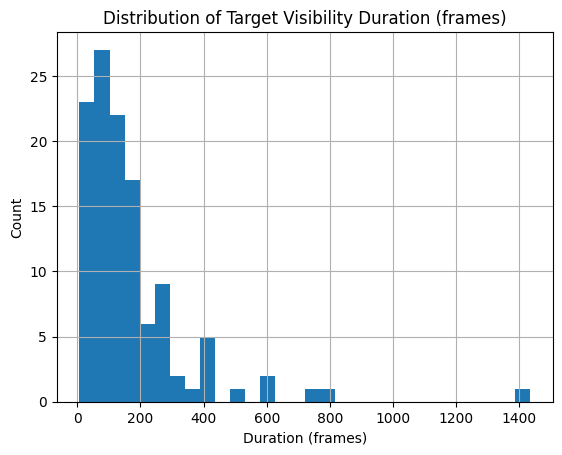

In [ ]:
df_ann['duration_frames'].hist(bins=30)
plt.title("Distribution of Target Visibility Duration (frames)")
plt.xlabel("Duration (frames)")
plt.ylabel("Count")


Text(0.5, 1.0, 'Object Appearance Intervals')

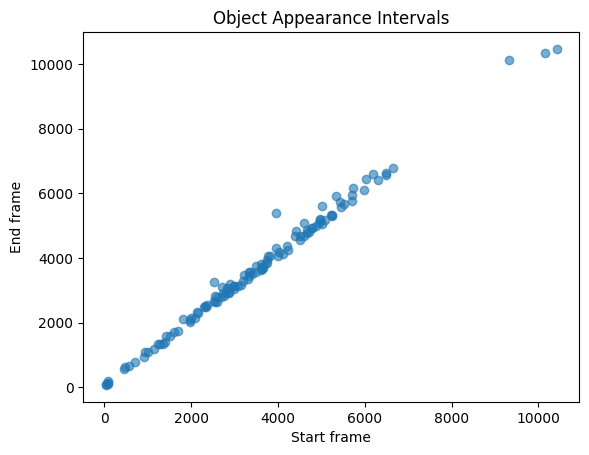

In [ ]:
plt.scatter(df_ann['start_frame'], df_ann['end_frame'], alpha=0.6)
plt.xlabel('Start frame'); plt.ylabel('End frame')
plt.title('Object Appearance Intervals')


In [ ]:
areas = []
for record in eda.annotations:
    for ann in record["annotations"]:
        for b in ann["bboxes"]:
            area = (b["x2"] - b["x1"]) * (b["y2"] - b["y1"])
            areas.append(area)
print("Mean box area:", np.mean(areas))

Mean box area: 1694.269637910566
